# set up

In [7]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [8]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [256]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=798911424,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
#                    stimulus_condition_id=[249, 256, 257, 260, 261, 268, 270, 274, 275, 278, 280, 281, 284],
#                    stimulus_condition_id=[275, 246, 268, 270, 284, 274, 249, 263, 261, 286, 258, 278, 267, 280, 256, 
#                                           260, 257, 281],
                   stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
                                          262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 274, 275, 276, 277,
                                          278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


In [ ]:
# Load selected group_id
import pickle
with open('group_id_79/membership_79.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_79/condition_ids_79.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [250]:
# Select top 20% of neurons as cross-pop
# condition_ids = [249, 256, 257, 260, 261, 268, 270, 274, 275, 278, 280, 281, 284]
condition_ids = [275, 246, 268, 270, 284, 274, 249, 263, 261, 286, 258, 278, 267, 280, 256, 260, 257, 281]
# condition_ids = [246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                   262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 274, 275, 276, 277,
#                   278, 279, 280, 281, 282, 283, 284, 285, 286, 270]
membership = []
spike_train = V1.spike_train
for current_condition in condition_ids:
    submembership_list = []
    for probe_name in probe_list:
        idx = V1._session.units[
            V1._session.units['ecephys_structure_acronym'].isin(utils.VISUAL_AREA) &
            V1._session.units['probe_description'].isin([probe_name])].index.values
        submembership = pd.DataFrame(index=idx)
        submembership.index.name = "unit_ids"
        submembership["probe"] = probe_name
        submembership["group_id"] = [-1]*len(idx)
        submembership["spike_count"] = [0]*len(idx)
        
        trial_ids = V1.presentation_table[V1.presentation_table['stimulus_condition_id']==current_condition].\
            index.values
        for neuron in idx:
            for trial_id in trial_ids:
                submembership.loc[neuron, "spike_count"] += np.sum(spike_train.loc[neuron][trial_id])
        cutoff = np.quantile(submembership["spike_count"].values, 0.8)
        for neuron in idx:
            if submembership.loc[neuron, "spike_count"] >= cutoff:
                submembership.loc[neuron, "group_id"] = 0
            else:
                submembership.loc[neuron, "group_id"] = 1
        submembership_list.append(submembership)
    current_membership = pd.concat(submembership_list)
    membership.append(current_membership)

In [175]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

mean_num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id']==0)]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons in cross-pop in average. ")
    mean_num_neuron.append(np.mean(num_cross_pop))

probeA has 17.846153846153847 neurons in cross-pop in average. 
probeB has 10.435897435897436 neurons in cross-pop in average. 
probeC has 15.897435897435898 neurons in cross-pop in average. 
probeD has 11.948717948717949 neurons in cross-pop in average. 
probeE has 10.64102564102564 neurons in cross-pop in average. 
probeF has 11.538461538461538 neurons in cross-pop in average. 


In [176]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id'].isin([0,1,2]))]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons. ")
    num_neuron.append(np.mean(num_cross_pop))

probeA has 78.0 neurons. 
probeB has 57.0 neurons. 
probeC has 94.0 neurons. 
probeD has 78.0 neurons. 
probeE has 89.0 neurons. 
probeF has 47.0 neurons. 


# Fit six areas with 14 conditions

## Record of AIC and BIC to decide couping filter hyperparameters

num_f_refractory = 4
max_iter = 10
self_effect = False
tau = 15
coupling_filter_params = {'peaks_max':15.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 3e-1
AIC improvement of the model is: 6857.286720926291
BIC improvement of the model is: 9403.707517772797

num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1
AIC improvement of the model is: 6693.236375827226
BIC improvement of the model is: 9239.657172673731

num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':30, 'num':4, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 3e-1
AIC improvement of the model is: 7294.3920674029505
BIC improvement of the model is: 9204.207665037946

## Fit

In [257]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1
use_all = False

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params, use_all=use_all)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True, 
                     use_all=use_all)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty, use_all=use_all)
    running_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        running_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(intermediate=False, ci=True)
    for j in range(len(model.basis_list)):
        running_output[i,j-1] = output_list[j]
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params, use_all=use_all)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True, 
                     use_all=use_all)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty, use_all=use_all)
    stationary_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        stationary_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(intermediate=False, ci=True)
    for j in range(len(model.basis_list)):
        stationary_output[i,j-1] = output_list[j]
    
    # for effect filter
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    
    # for effect output
    filter_index = i,-1
    function1 = np.exp( running_output[filter_index][0] )
    function2 = np.exp( stationary_output[filter_index][0] )
    ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_output[filter_index][0]
        function2 = stationary_output[filter_index][0]
        ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)

# aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
# baseline_aic = 570714.232742189
# print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

# bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
# baseline_bic = 588924.4932276756
# print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [12:57, 129.61s/it]


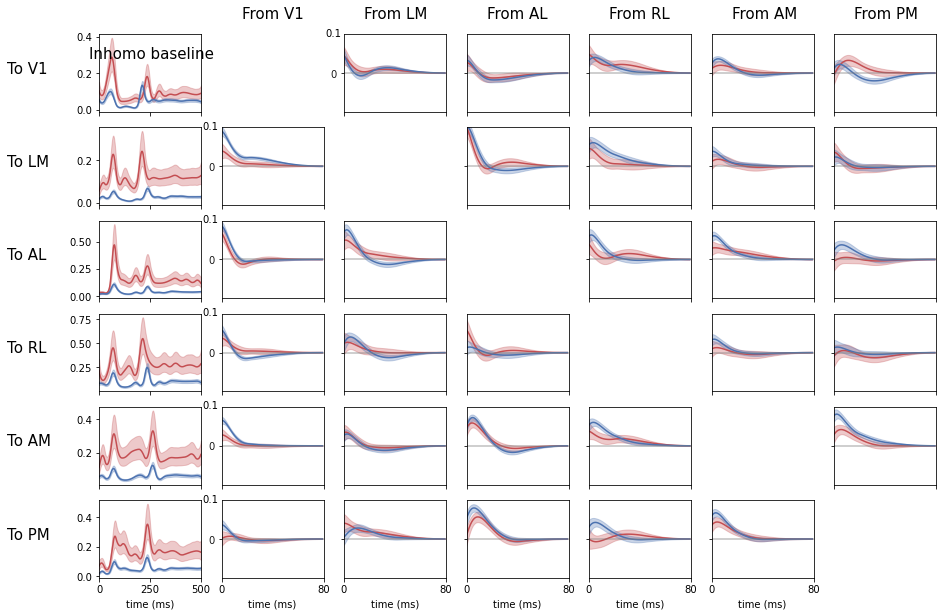

In [221]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False, output=False, filter_amp=0.1)

Text(0.5, 1.0, 'Fitted with $f_{rf}(\\Lambda)$ model; LM; Resting; trial 85')

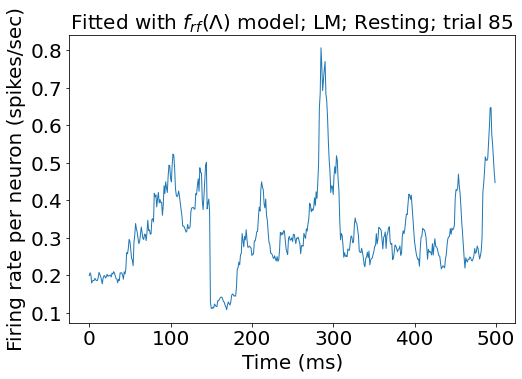

In [21]:
fontsize = 20
plt.subplots(figsize=(8,5.3))

# plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85])/10.625*1e3, linewidth=1)
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]), linewidth=1)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Time (ms)", fontsize=fontsize)
plt.ylabel("Firing rate per neuron (spikes/sec)", fontsize=fontsize)
plt.title("Fitted with $f_{rf}(\Lambda)$ model; LM; Resting; trial 85", fontdict = {'fontsize' : 20})

Text(0.5, 1.0, '$\\beta_{V1, m}$')

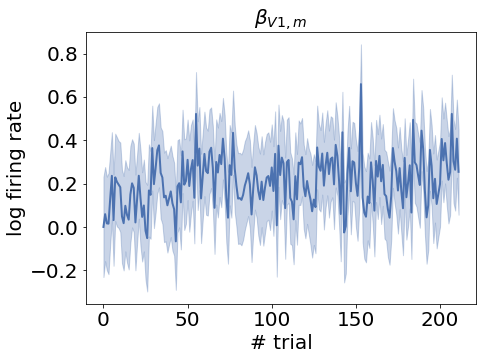

In [22]:
fontsize = 20
plt.subplots(figsize=(5*1.4,5))

utils.plot_ci(stationary_model_list[2].get_filter(ci=True)[8], center=True, linewidth=2)

plt.xlabel('# trial', fontsize=fontsize)
plt.ylabel('log firing rate', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\beta_{V1, m}$', fontdict = {'fontsize' : 20})

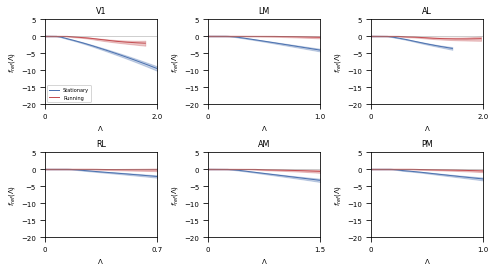

In [23]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9,3.8))
transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}
xrange = [200, 100, 200, 70, 150, 100]

model_list = stationary_model_list + running_model_list
for ii in range(6):
    i = transfer_ij[ii]

    plt.subplot(2,3, ii+1)
    model = model_list[i]
    utils.plot_ci(model.get_filter(ci=True)[7], center=True, color='b', label="Stationary")
    plt.xlabel('$\Lambda$')
    plt.ylabel('$f_{rf}(\Lambda)$')
    plt.ylim([-20, 5])
    plt.xlim([0, 200])
    plt.xticks([0, 100, 200], [0, 1, 2])
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Resting")

    plt.subplot(2,3, ii+1)
    model = model_list[i+6]
    utils.plot_ci(model.get_filter(ci=True)[7], center=True, color='r', label="Running")
    plt.xlabel('$\Lambda$')
    plt.ylabel('$f_{ref}(\Lambda)$')
    plt.ylim([-20, 5])
    plt.xlim([0, xrange[ii]])
    plt.xticks([0, xrange[ii]], [0, xrange[ii]/100])
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]])
    plt.axhline(0, ls='-', color='grey', lw=0.75, alpha=0.5)
    if ii == 0:
        plt.legend()
plt.tight_layout()
# plt.savefig('Figures/f_ref.svg', format='svg', dpi=300)

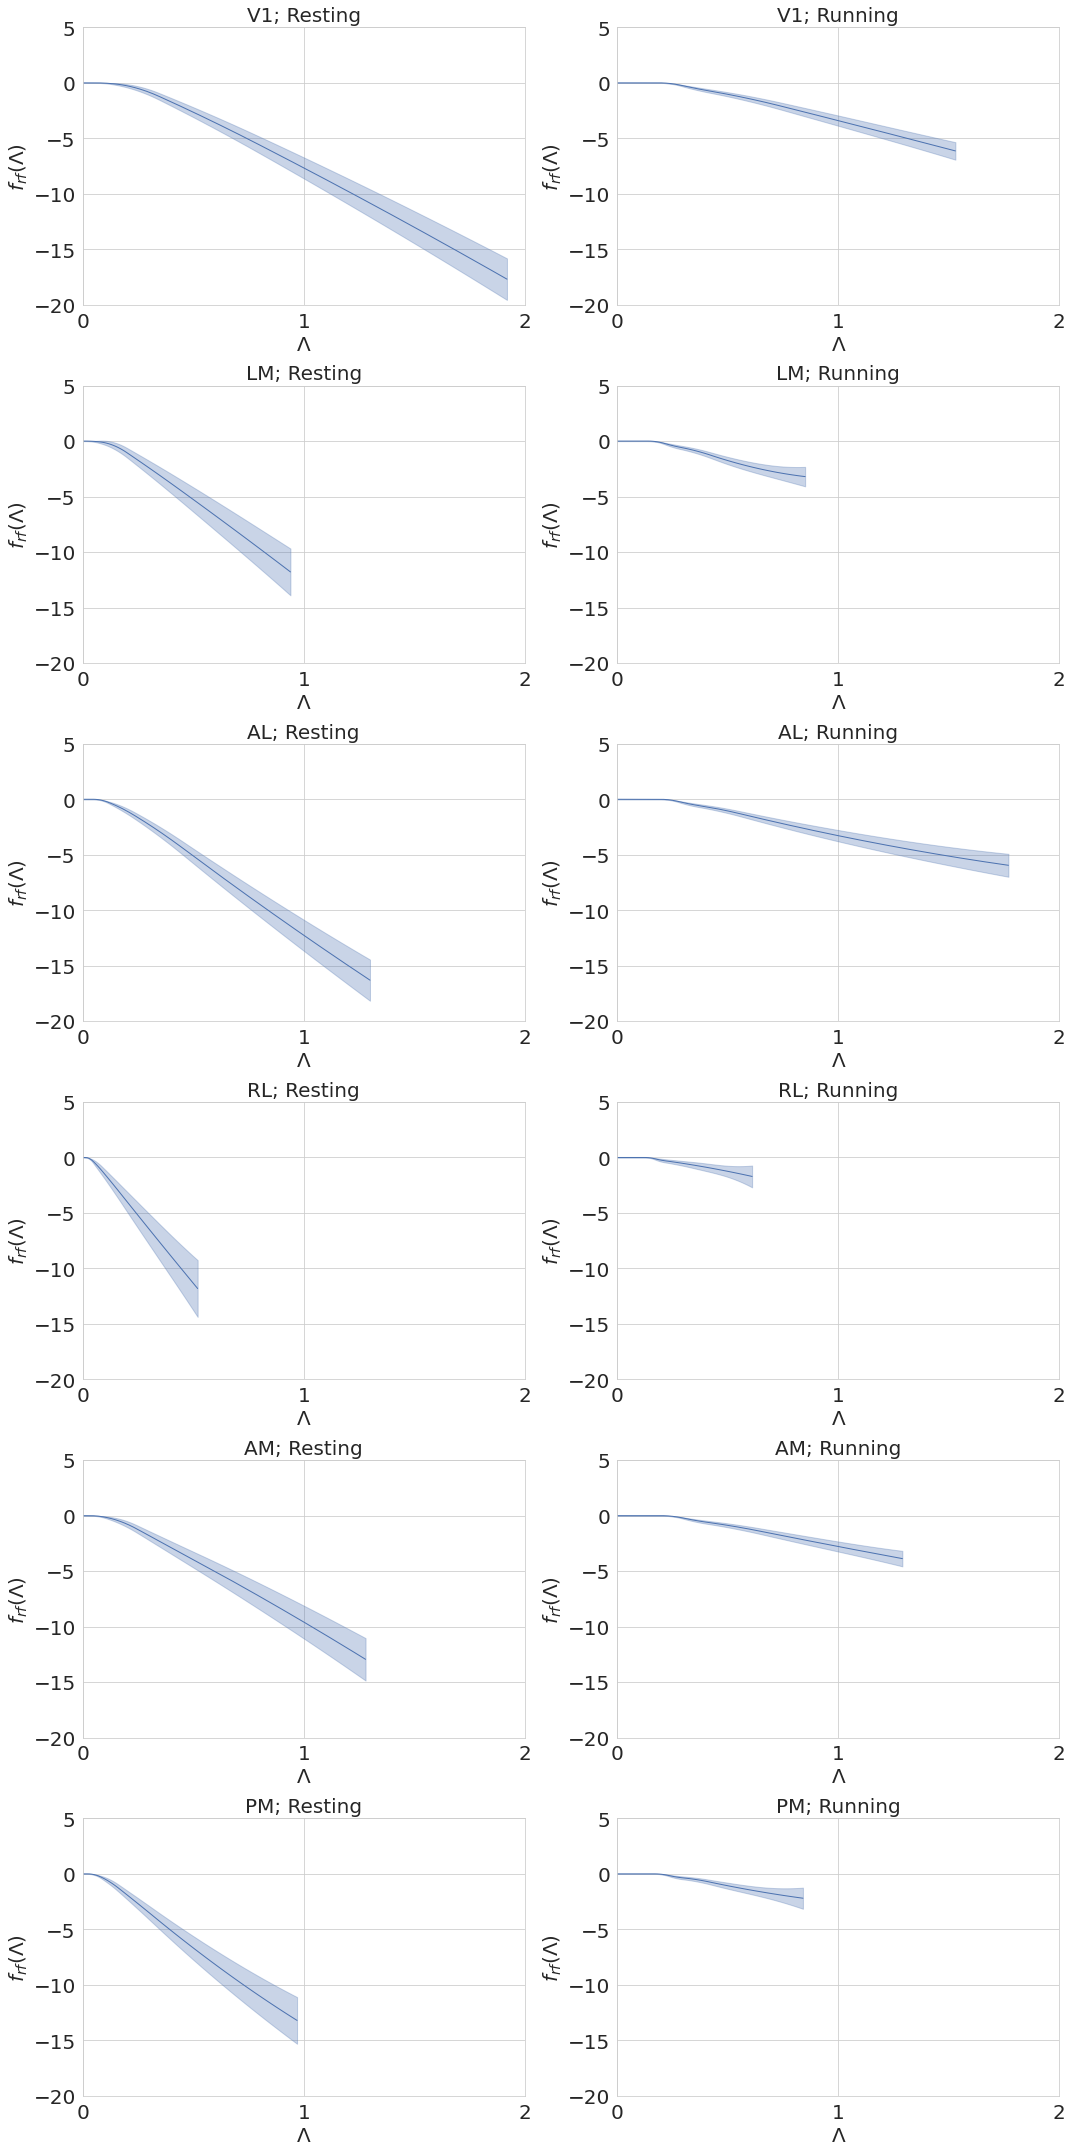

In [294]:
sns.set_style('whitegrid')
fontsize = 20
plt.subplots(figsize=(15,30))
transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}

model_list = stationary_model_list + running_model_list
for ii in range(6):
    i = transfer_ij[ii]
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-6)
        model = model_list[i]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Resting", fontdict = {'fontsize' : 20})
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-5)
        model = model_list[i+6]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Running", fontdict = {'fontsize' : 20})
plt.tight_layout()
sns.set_style('white')


In [77]:
# Save peak times, which turned out to be not useful. 
fix_peak_time = []
for i_probe in range(6):
    fix_peak_time_single = np.zeros((V1.ntrial, 4))
    i_stationary = 0
    i_running = 0
    for itrial in range(V1.ntrial):
        if stationary_model_list[0].select_trials[itrial] == True:
            fix_peak_time_single[itrial, 1] = stationary_model_list[i_probe].shifts[i_stationary,1]
            fix_peak_time_single[itrial, 3] = stationary_model_list[i_probe].shifts[i_stationary,3]
            fix_peak_time_single[itrial, 0] = stationary_model_list[i_probe].shifts[i_stationary,0]
            fix_peak_time_single[itrial, 2] = stationary_model_list[i_probe].shifts[i_stationary,2]
            i_stationary += 1
        else:
            fix_peak_time_single[itrial, 1] = running_model_list[i_probe].shifts[i_running,1]
            fix_peak_time_single[itrial, 3] = running_model_list[i_probe].shifts[i_running,3]
            fix_peak_time_single[itrial, 0] = running_model_list[i_probe].shifts[i_running,0]
            fix_peak_time_single[itrial, 2] = running_model_list[i_probe].shifts[i_running,2]
            i_running += 1
    fix_peak_time.append(fix_peak_time_single)

## Merge distributed null values

In [258]:
# server_names = ["exxact1", 
#                 "hydra4.", "hydra5.", "hydra6.", "hydra7.", "hydra8.", 
#                 "hydra9.", "hydra10", "hydra11", "hydra12", "hydra13"]

server_names = ["hydra9.", "hydra11", "hydra12", "hydra13"]

filter_unmerged = []
output_unmerged = []
for server_name in server_names:
    with open("79Nullallconditions/79statistics_null_filter_"+server_name+".pickle", 'rb') as handle:
        filter_unmerged.append(pickle.load(handle))
    with open("79Nullallconditions/79statistics_null_output_"+server_name+".pickle", 'rb') as handle:
        output_unmerged.append(pickle.load(handle))

statistics_null_filter = GLM.merge_dict_multi(filter_unmerged)
statistics_null_output = GLM.merge_dict_multi(output_unmerged)

In [259]:
# Number of samples
len(statistics_null_filter[0, 1])

350

# Filters and inference on filters

In [616]:
0.00228*30

0.0684

In [615]:
0.00007*30

0.0021

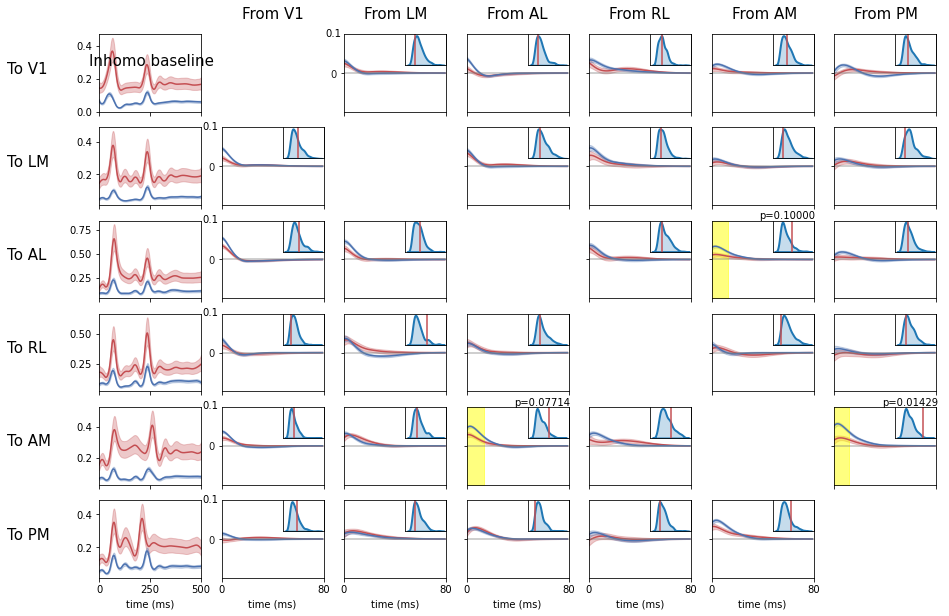

In [260]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, 
                                statistics_filter=statistics_filter, 
                                statistics_null_filter=statistics_null_filter, 
                                ROI_filter=ROI_filter, 
                                output=False,
                               filter_amp=0.10
                              )
# plt.savefig('Figures/Filters.svg', format='svg', dpi=300)

# Output and inference on output

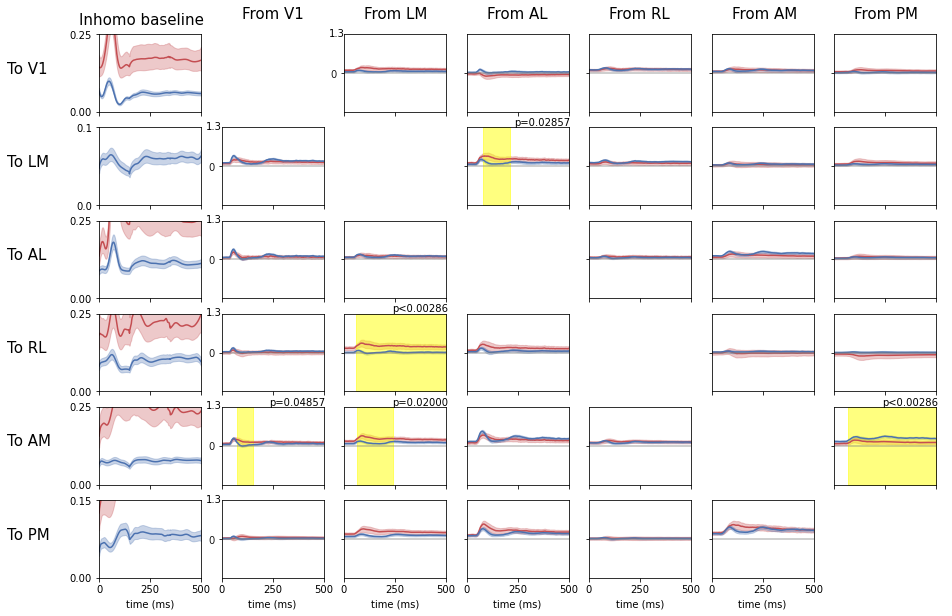

In [261]:
GLM.plot_output_with_excursion(V1, stationary_output, running_output, 
                                statistics_output=statistics_output, 
                                statistics_null_output=statistics_null_output, 
                                ROI_output=ROI_output
                              )
# plt.savefig('Figures/Outputs.svg', format='svg', dpi=300)

# Mean firing rate (spikes per sec per neuron)

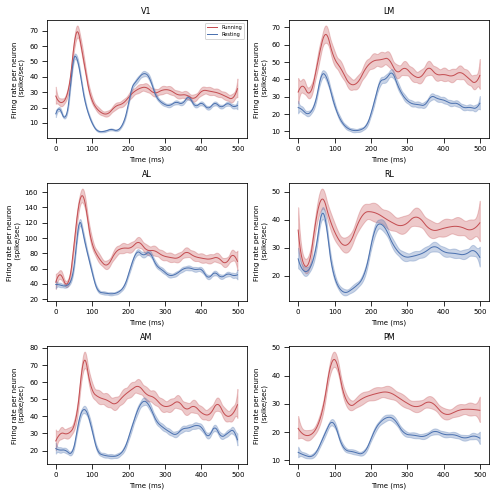

In [17]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9,6.9))

transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}
num_basis_baseline1 = [25,25,25,25-10,25,25-10]
num_basis_baseline2 = [30,30,30,30-10,30,30-10]
probe_list = V1.selected_probes

for ii, target_probe in enumerate(probe_list):
    i = transfer_ij[ii]
    plt.subplot(3, 2, ii+1)
    
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline1[ii], add_constant_basis=False)
    model.fit(probe_list[i], verbose=False, penalty=1e0, use_all=True)
    x = model.dataset.time_line*1e3
    y, ci = model.get_filter_output(ci=True, intermediate=False)[0]
    color = 'r'
    label = 'Running'
    plt.plot(x, np.exp(y.squeeze())*1e3/mean_num_neuron[i],label=label, color=color)
    plt.fill_between(x, np.exp(y-2*ci)*1e3/mean_num_neuron[i], np.exp(y+2*ci)*1e3/mean_num_neuron[i], 
                     color=color, alpha=.3)
#     plt.plot(x,1e3*utils.kernel_smoothing(model.output.mean(axis=1)[:, np.newaxis], std=15)/num_neuron[i],
#              label=label, color=color, linewidth=3)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline2[ii], add_constant_basis=False)
    model.fit(probe_list[i], verbose=False, penalty=1, use_all=True)
    x = model.dataset.time_line*1e3
    y, ci = model.get_filter_output(ci=True, intermediate=False)[0]
    color = 'b'
    label = 'Resting'
    plt.plot(x, np.exp(y.squeeze())*1e3/mean_num_neuron[i],label=label, color=color)
    plt.fill_between(x, np.exp(y-2*ci)*1e3/mean_num_neuron[i], np.exp(y+2*ci)*1e3/mean_num_neuron[i],
                     color=color, alpha=.3)
#     plt.plot(x,1e3*utils.kernel_smoothing(model.output.mean(axis=1)[:, np.newaxis], std=15)/num_neuron[i],
#              label=label, color=color, linewidth=3)
    plt.xlabel('Time (ms)')
    plt.ylabel('Firing rate per neuron \n (spike/sec)')

    if ii==0:
        plt.legend()
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]])
    plt.tight_layout()
    
# plt.savefig('Figures/Mean_FR.svg', format='svg', dpi=300)

# Basis and illustration of excursion test

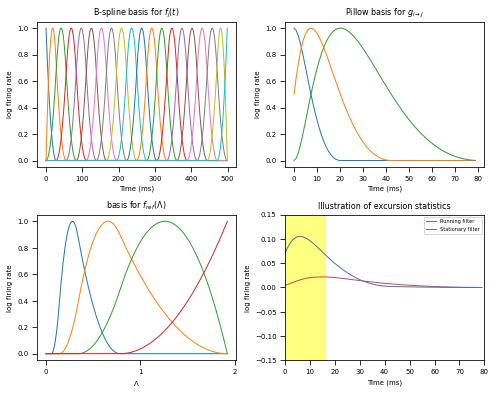

In [1031]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9,5.5))
model_list = stationary_model_list + running_model_list

plt.subplot(2,2,1)
plt.plot(np.arange(model_list[2].basis_list[0].shape[0])*1, model_list[2].basis_list[0])
plt.xlabel('Time (ms)')
plt.ylabel('log firing rate')
plt.title('B-spline basis for $f_j(t)$')

plt.subplot(2,2,2)
plt.plot(np.arange(model_list[2].basis_list[1].shape[0])*1, model_list[2].basis_list[1])
plt.xlabel('Time (ms)')
plt.ylabel('log firing rate')
plt.title(r'Pillow basis for $g_{i \rightarrow j}$')

plt.subplot(2,2,3)
plt.plot(np.arange(model_list[2].basis_list[7].shape[0])*1e-2, model_list[2].basis_list[7])
plt.xlabel('$\Lambda$')
plt.ylabel('log firing rate')
plt.xticks([0, 1, 2], [0, 1, 2])
plt.title('basis for $f_{ref}(\Lambda)$')

plt.subplot(2,2,4)
i, j = 4,3
filter_amp = 0.15
i_plot = transfer_ij[i]
j_plot = transfer_ij[j]
filter_length = 80
fontsize = 15
filter_index = i_plot,j_plot
#         print(filter_index)
y, ci = running_filter[filter_index]
x = np.arange(y.shape[0])
plt.plot(x, y,label='Running filter', color='r')
y, ci = stationary_filter[filter_index]
x = np.arange(y.shape[0])
plt.plot(x, y,label='Stationary filter', color='b')
for temp in ROI_filter[filter_index]:
    x = np.array([temp.min(), temp.max()])
    plt.fill_between(x, np.array([-filter_amp,-filter_amp]), np.array([filter_amp,filter_amp]), \
                     color='yellow', alpha=.5)
plt.title("Illustration of excursion statistics")

plt.ylim([-filter_amp, filter_amp])
plt.xlim([0, filter_length])
plt.legend()
plt.xlabel('Time (ms)')
plt.ylabel('log firing rate')
plt.tight_layout()
# plt.savefig('Figures/Basis.svg', format='svg', dpi=300)

# Mean outputs from all trials in one plot

In [1035]:
stationary_model_list[3].basis_name

['time_warping_inhomogeneous_baseline',
 'coupling from AM',
 'coupling from PM',
 'coupling from V1',
 'coupling from LM',
 'coupling from AL',
 'coupling from RL',
 'refractory_additive',
 'trial_coef']

In [1036]:
to_look_at = 3
import copy
outputs = [stationary_model_list[to_look_at].get_filter_output(ci=False)[i] for i in range(9)]
outputs[to_look_at+1] += outputs[7]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 8):
    total_output += outputs[i]

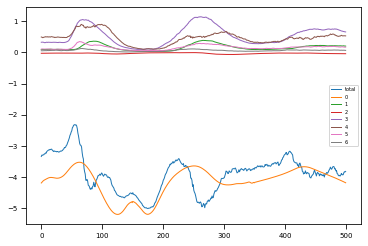

In [1039]:
plt.plot(total_output, label='total')
for i, output in enumerate(outputs[:7]):
    plt.plot( output ,label=str(i))
plt.legend()

# Plot all effect's output in an example trial

In [1051]:
to_look_at = 1
import copy
model = stationary_model_list[transfer_ij[to_look_at]]
outputs = []
for ii in range(9):
    if ii>=0 and ii<=5:
        i = transfer_ij[ii]
    else:
        i = ii
    outputs.append( model.get_filter_output(trial_wise=True, ci=False)[i].\
                   reshape((model.nt, model.ntrial), order='F')  )

outputs[transfer_ij[to_look_at]+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]


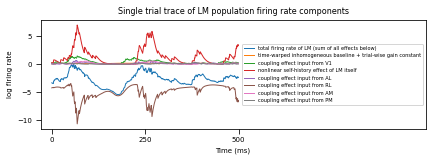

In [1091]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9,2))

trial = 2

plt.plot(total_output[:,trial], label='total')
for i in range(7):
    output = outputs[i]
    plt.plot( output[:,trial])

plt.legend(['total firing rate of LM (sum of all effects below)', 
            'time-warped inhomogeneous baseline + trial-wise gain constant', 
            'coupling effect input from V1', 
            'nonlinear self-history effect of LM itself', 
            'coupling effect input from AL',
            'coupling effect input from RL',
            'coupling effect input from AM',
            'coupling effect input from PM'], 
            loc='center right')
plt.xlim([-30, 1000])
plt.xticks([0, 250, 500], [0, 250, 500])
plt.ylabel('log firing rate')
plt.xlabel('Time (ms)')
plt.title('Single trial trace of LM population firing rate components')
# plt.savefig('Figures/Single_trace.svg', format='svg', dpi=300)

Text(0.5, 0, 'Time (ms)')

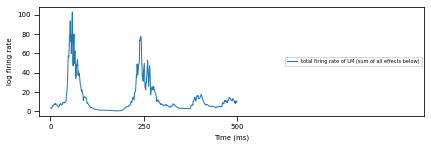

In [1088]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9,2))

trial = 2

plt.plot(1e2*np.exp(total_output[:,trial]), label='total')


plt.legend(['total firing rate of LM (sum of all effects below)', 
            'time-warped inhomogeneous baseline + trial-wise gain constant', 
            'coupling effect input from V1', 
            'nonlinear self-history effect of LM itself', 
            'coupling effect input from AL',
            'coupling effect input from RL',
            'coupling effect input from AM',
            'coupling effect input from PM'], 
            loc='center right')
plt.xlim([-30, 1000])
plt.xticks([0, 250, 500], [0, 250, 500])
plt.ylabel('log firing rate')
plt.xlabel('Time (ms)')

Text(0.5, 0, 'time (ms)')

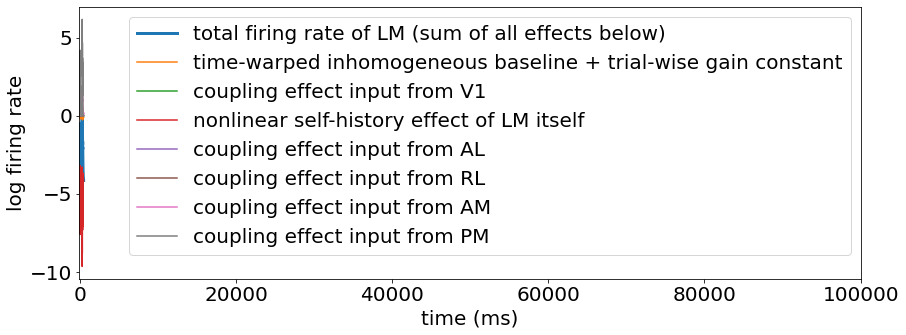

In [1052]:
sns.reset_orig()
trial = 1
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(14,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.legend(['total firing rate of LM (sum of all effects below)', 
            'time-warped inhomogeneous baseline + trial-wise gain constant', 
            'coupling effect input from V1', 
            'nonlinear self-history effect of LM itself', 
            'coupling effect input from AL',
            'coupling effect input from RL',
            'coupling effect input from AM',
            'coupling effect input from PM'], fontsize=fontsize)
plt.xlim([-30, 100000])
plt.ylabel('log firing rate', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

Text(0.5, 0, 'time (ms)')

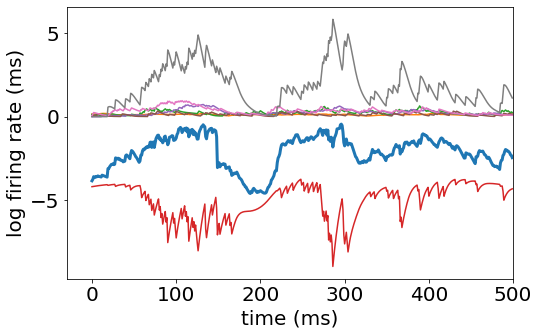

In [1053]:
sns.reset_orig()
trial = 0
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

# Simulation and explosion

## Explosion example

In [982]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
# coupling_filter_params = {'peaks_max':26, 'num':3, 'nonlinear':0.9}
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)


6it [06:25, 64.28s/it]


In [983]:
MAX_FIRING_RATE = 10
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = running_model_list
itrial = 1

import copy
import numpy.random
nneuron = len(model_list)
# Get three dimension matrix of coupling filters for better computing. 
max_histories = 1
nt = model_list[0].nt
# allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef']
coupling_mat = np.zeros((max_histories, nneuron, nneuron))
baseline_mat = np.zeros((nt, nneuron))
spikes = np.zeros((nt, nneuron, 1))
probe2num = {}
for iprobe, probe in enumerate(probe_list):
    probe2num[probe] = iprobe

for ineuron in range(nneuron):
    assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
    model = model_list[ineuron]
    for ieffect, effect_type in enumerate(model.effect_type_list):
        
        if effect_type in ['inhomogeneous_baseline', ]:
            baseline_mat[:, ineuron] = model.filters[ieffect]
            baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                       baseline_mat[:, ineuron][:,None], 
                                                                       model_list[ineuron].shifts[itrial,:][None,:], 
                                                                       model_list[ineuron].nt).squeeze()
            baseline_mat[:, ineuron] += model.results.params[model.trial_coef_start+itrial]
            
        elif effect_type in ['coupling']:
            nhistories = len(model.filters[ieffect])
            probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
            iprobe = probe2num[probe_name]
            if nhistories > max_histories:
                coupling_mat_old = coupling_mat
                coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                coupling_mat[-max_histories:, :, :] = coupling_mat_old
                max_histories = nhistories
            coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

log_firing_rate = baseline_mat[:,:,np.newaxis]
spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

recent_spike_sum = spikes[0, :, 0]

for t in range(1, nt):
    nhistories = min(t, max_histories)
    temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
    log_firing_rate[t,:,0] += temp_log_firing_rate
    log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
    spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

log_firing_rate = log_firing_rate.squeeze()
spikes = spikes.squeeze()

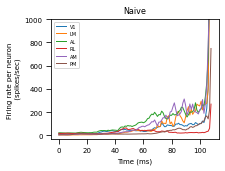

In [985]:
utils.use_pdf_plot()
plt.subplots(figsize=(3,2.2))
try:
    to_plot_end = np.where(log_firing_rate.squeeze().max(axis=1)>=10)[0][0]
    for ii in range(6):
        i = transfer_ij[ii]
        plt.plot(np.exp(log_firing_rate.squeeze()[:to_plot_end,i])*1e3/(mean_num_neuron[i]))
except IndexError:
    plt.plot(np.exp(log_firing_rate.squeeze()[:,:])*1e3/np.array(mean_num_neuron)[np.newaxis, :])
plt.legend(['V1','LM','AL','RL','AM','PM'])
plt.title("Naive")
plt.ylim([-30, 1000])
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate per neuron \n (spikes/sec)')
# plt.xlim([0, 500])
# plt.savefig('Figures/Explosion.svg', format='svg', dpi=300)

## f_rf model doesn't explode

### Fit and simulate

In [986]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
# coupling_filter_params = {'peaks_max':26, 'num':3, 'nonlinear':0.9}
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    

6it [08:46, 87.80s/it]


In [987]:
# Simulate stationary
stationary_results = GLM.simulate_baseline_coupling_refractory(stationary_model_list, 
                                                               nepoch=1, offset=0.07)

100%|██████████████████████████████████████| 1/1 [00:28<00:00, 28.52s/it]


In [988]:
# Simulate running
running_results = GLM.simulate_baseline_coupling_refractory(running_model_list, 
                                                            nepoch=1, offset=0.09)

100%|██████████████████████████████████████| 1/1 [00:12<00:00, 12.52s/it]


### PSTH compare

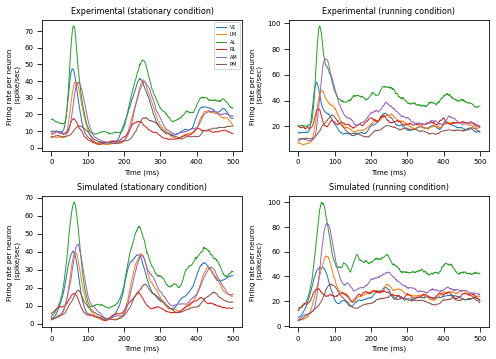

In [914]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9,5))
name_list = ['V1', 'LM', 'AL', 'RL', 'AM', 'PM']

plt.subplot(2, 2, 1)
for ii in range(6):
    i = transfer_ij[ii]
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(stationary_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=name_list[ii])
plt.legend()
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate per neuron \n (spike/sec)')
plt.title('Experimental (stationary condition)')

plt.subplot(2, 2, 2)
for ii in range(6):
    i = transfer_ij[ii]
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(running_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=name_list[ii])
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate per neuron \n (spike/sec)')
plt.title('Experimental (running condition)')

plt.subplot(2, 2, 3)
spikes_rcd = stationary_results[0]
for ii in range(6):
    i = transfer_ij[ii]
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=name_list[ii])
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate per neuron \n (spike/sec)')
plt.title('Simulated (stationary condition)')

plt.subplot(2, 2, 4)
spikes_rcd = running_results[0]
for ii in range(6):
    i = transfer_ij[ii]
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=name_list[ii])
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate per neuron \n (spike/sec)')
plt.title('Simulated (running condition)')

plt.tight_layout()
# plt.savefig('Figures/PSTH.svg', format='svg', dpi=300)

### Single trial plot

Text(0.5, 1.0, 'Stationary condition')

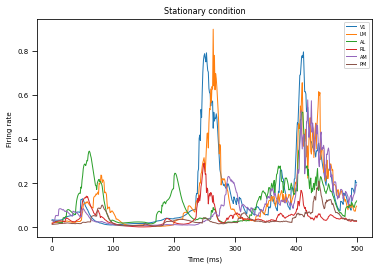

In [937]:
log_firing_rate = stationary_results[1]
itrial = 13

for ii in range(6):
    i = transfer_ij[ii]
    plt.plot(np.exp(log_firing_rate[:, itrial, i])*1e3/(mean_num_neuron[i]))
plt.legend(['V1','LM','AL','RL','AM','PM'])
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate')
plt.title('Stationary condition')

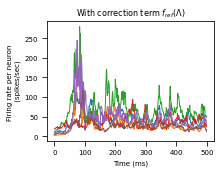

In [1034]:
log_firing_rate = running_results[1]
itrial = 2

utils.use_pdf_plot()
plt.subplots(figsize=(3,2.2))
for ii in range(6):
    i = transfer_ij[ii]
    plt.plot(np.exp(log_firing_rate[:, itrial, i])*1e3/(mean_num_neuron[i]))
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate per neuron \n (spikes/sec)')
plt.title('With correction term $f_{ref}(\Lambda)$')
# plt.savefig('Figures/NonExplosion.svg', format='svg', dpi=300)

### Correlation and partial correlation are not captured well in our model

Doesn't really work

In [592]:
peaks_rcd = np.concatenate((stationary_results[2], running_results[2]), axis=1)
peaks_rcd.shape

(2, 210, 6)

In [593]:
GLM.corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.47500245, 0.49626004],
       [0.47500245, 1.        , 0.42545703],
       [0.49626004, 0.42545703, 1.        ]])

In [594]:
GLM.partial_corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.45417127, 0.45959725],
       [0.45417127, 1.        , 0.36032551],
       [0.45959725, 0.36032551, 1.        ]])